### `test_rd_solvers.ipynb`
In this notebook we test out the 1D reaction-diffusion solvers on some reaction diffusion PDEs of the form 
$$u_t = Du_{xx} + f(u) $$

In [1]:
using NBInclude
@nbinclude("rd_solvers_1D.ipynb")
@nbinclude("../rd_visualization.ipynb")

# result = setprecision((), BigFloat, 256) do 
#     ...calculation 
# end

In [2]:
#Example: Single-Species 

f(u,x,t,p) = -(u - 1.0)*(u - 2.0)*(u-3.0)
u0_fun(x) = 10.0 .* sin(x)

sol = rd_solve_one_species(;f = f, D = 0.01, u0_fun = u0_fun, ℓ = 3.14, tspan = (0.0,50.0), N = 64, dt = 0.1,
                            p = nothing, solver = etd_rk4);

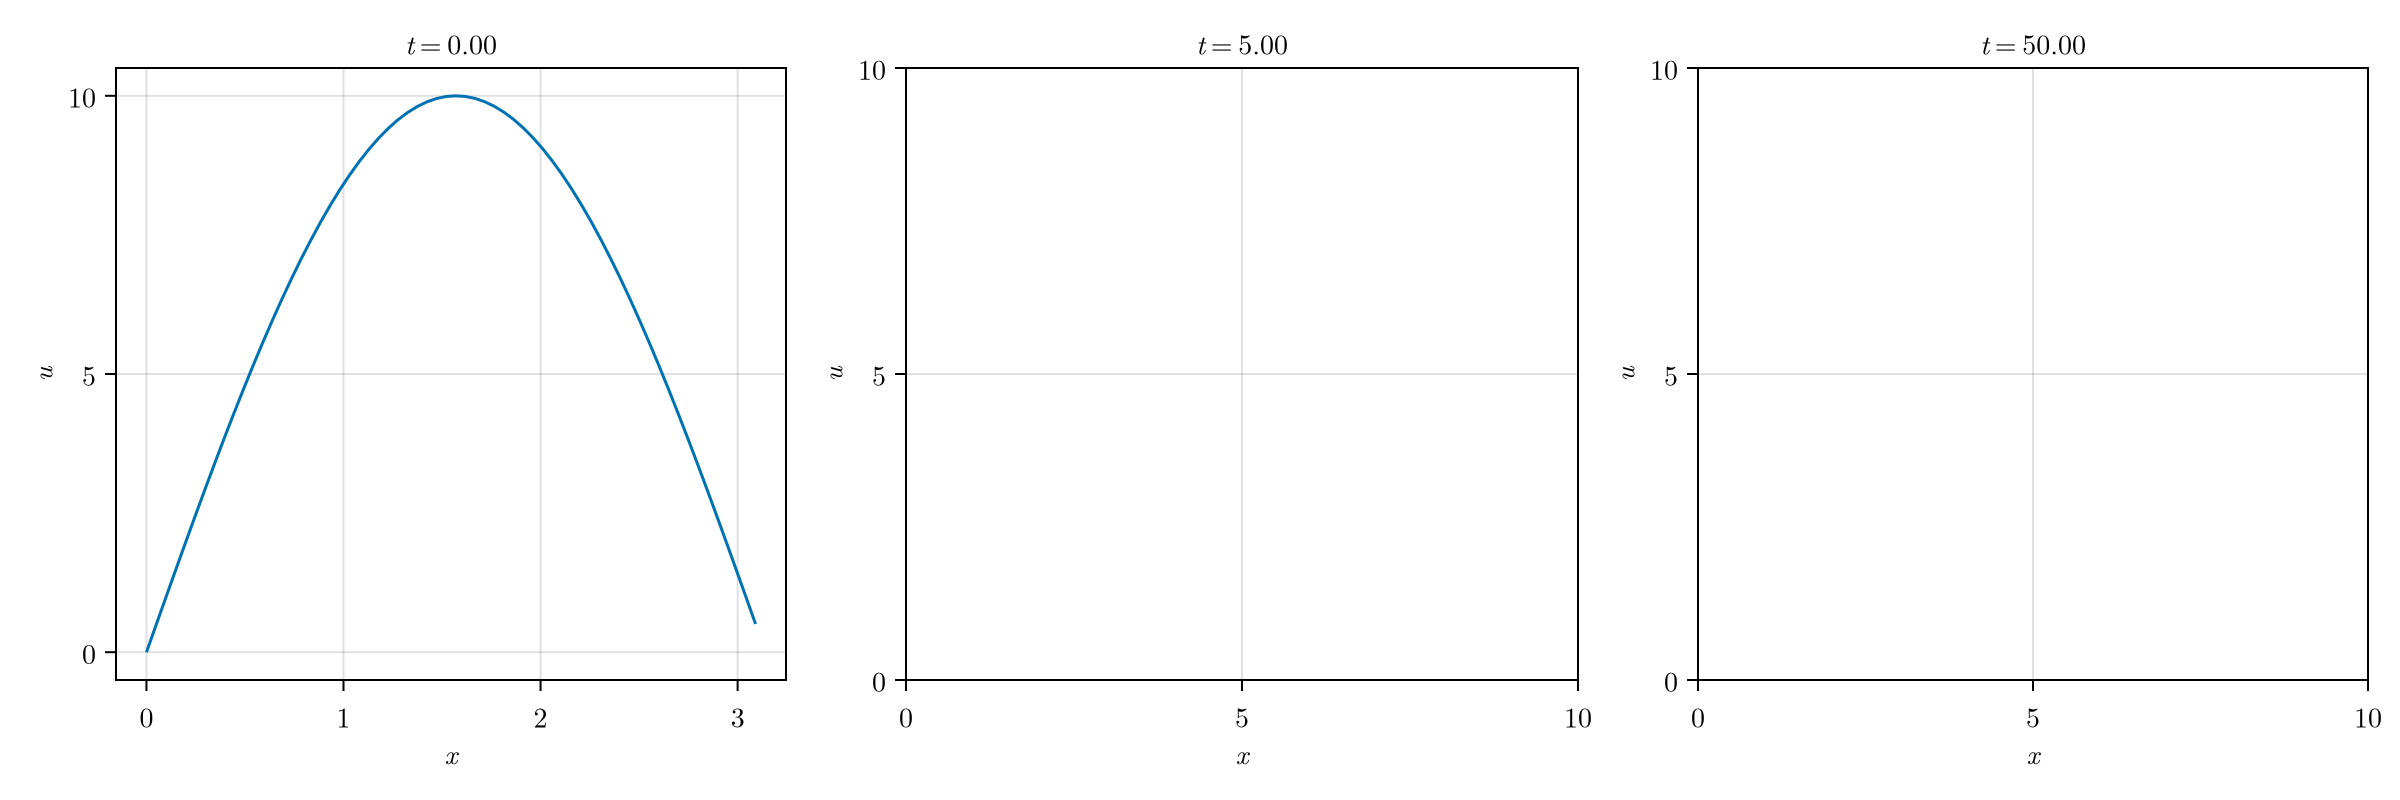

In [4]:
plot_profiles_one_species(sol; plot_times = [0.0, 5.0, 50.0], 
                          size=(400, 400), axislabelsize=nothing,
                          ticklabelsize=nothing, titlesize=nothing)

In [17]:
#Example: Two-Species

mesa_params = (
    k0 = 0.05,   # basal activation rate
    γ  = 2.0,    # strength of positive feedback
    K  = 1.0,    # feedback half-saturation scale
    δ  = 1.0    # inactivation rate
)

function reaction(u, v, p)
    @unpack k0, γ, K, δ = p 
    return (k0 + γ * u^2 / (K^2 + u^2)) * v - δ * u
end

f_mesa(u, v, x, t, p) = reaction(u, v, p)
g_mesa(u, v, x, t, p) = -reaction(u, v, p)


#One localized Gaussian bump
u0_gaussian(x) = 0.05 + 1.8 * exp(-((x - 0.5) / 0.06)^2)

#One broad region with two sharp edges
u0_plateau(x) = 0.05 + 1.8 / (1.0 + exp((abs(x - 0.5) - 0.15) / 0.012))

#Two separated Gaussian bumps
u0_two_bumps(x) = 0.05 + 1.8 * exp(-((x - 0.2) / 0.05)^2) + 1.8 * exp(-((x - 0.3) / 0.05)^2)

v0_constant(x) = 1.0

u0_funcs = [u0_gaussian, u0_plateau, u0_two_bumps]

u0_funcs = [u0_two_bumps]

sols = []

for u0_fun in u0_funcs



    @time mesa_sol = rd_solve_two_species(
                        f = f_mesa,
                        g = g_mesa,
                        D_u = 0.00004,
                        D_v = 0.1,
                        u0_fun = u0_fun,
                        v0_fun = x -> 1.0,
                        ℓ = 1.0,
                        tspan = (0.0, 60.0),
                        dt = 0.001,
                        N = 256,
                        p = mesa_params
                    );

    push!(sols, mesa_sol)
end 

  7.956039 seconds (6.77 M allocations: 6.435 GiB, 53.18% gc time, 4.88% compilation time)
  6.646269 seconds (6.39 M allocations: 6.416 GiB, 38.22% gc time, 1.00% compilation time)
  6.955625 seconds (6.39 M allocations: 6.416 GiB, 32.06% gc time, 1.01% compilation time)


In [12]:
D_u = 0.0004
η = 1.0
ℓ = 1.0
ϵ = sqrt(D_u / η) / ℓ

0.02

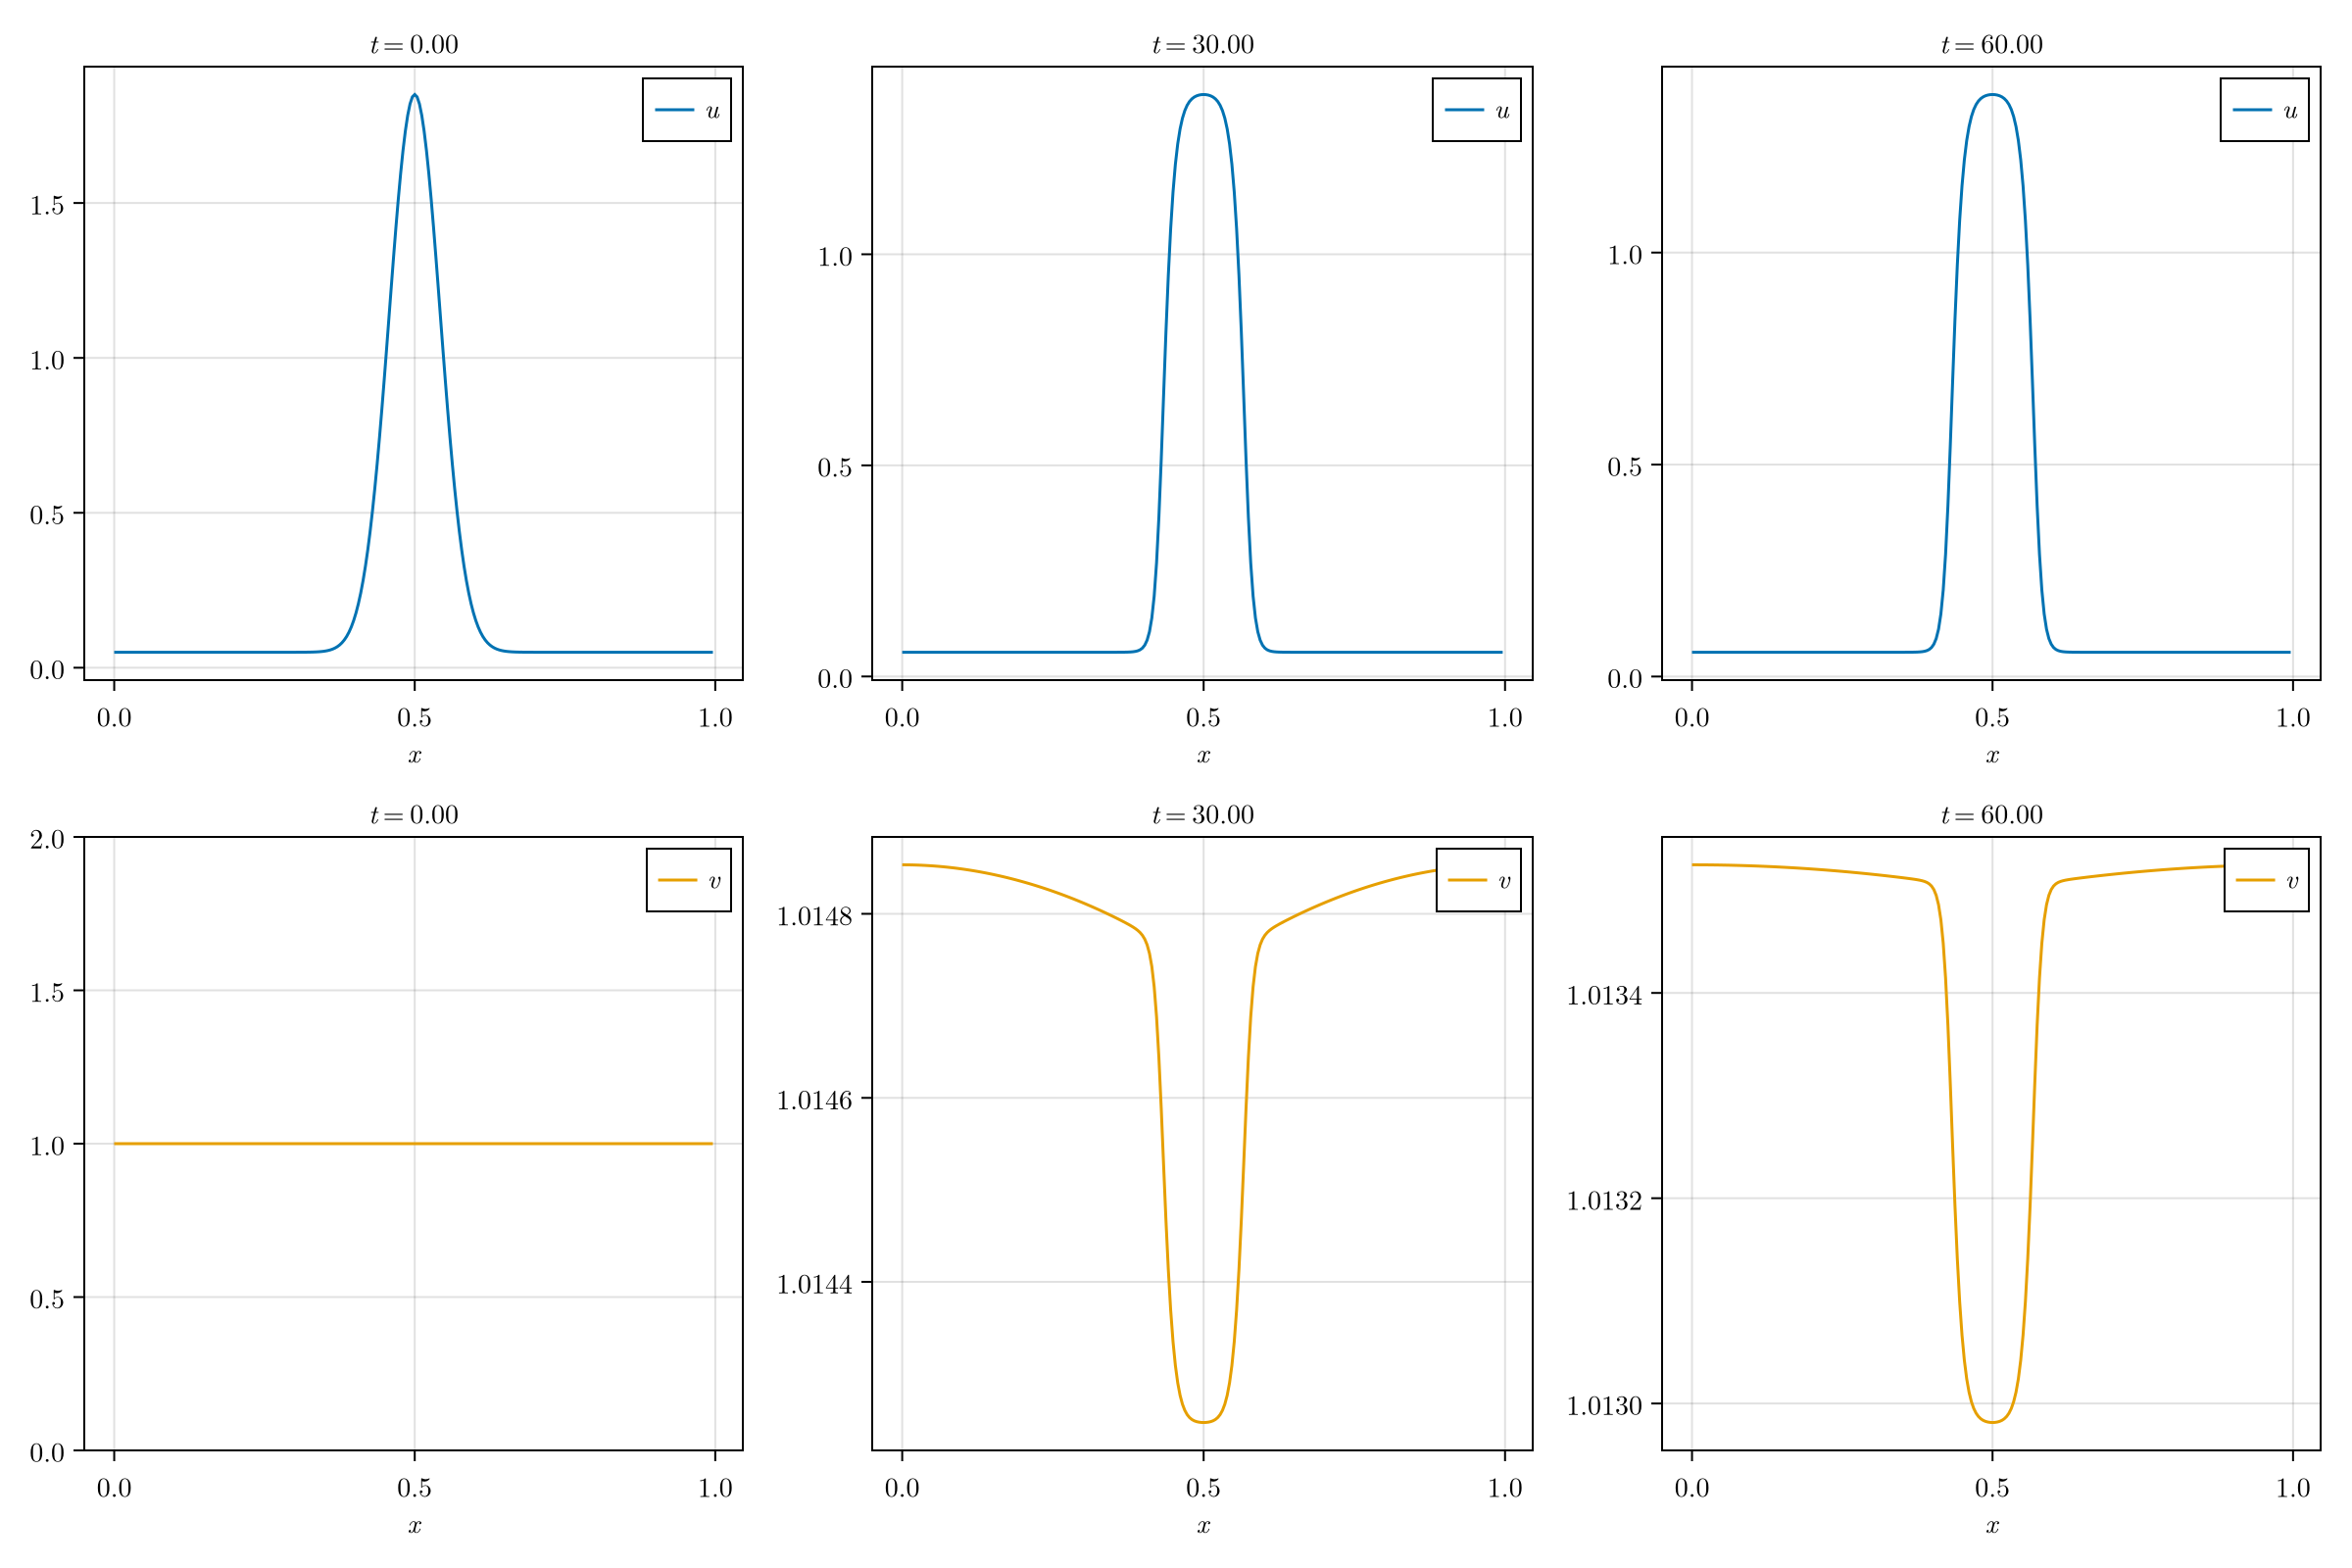

In [14]:
plot_profiles(sols[1]; plot_times = [0.0, 30.0, 60.0], size = (400,400), axislabelsize = nothing,
                        ticklabelsize = nothing, titlesize = nothing)

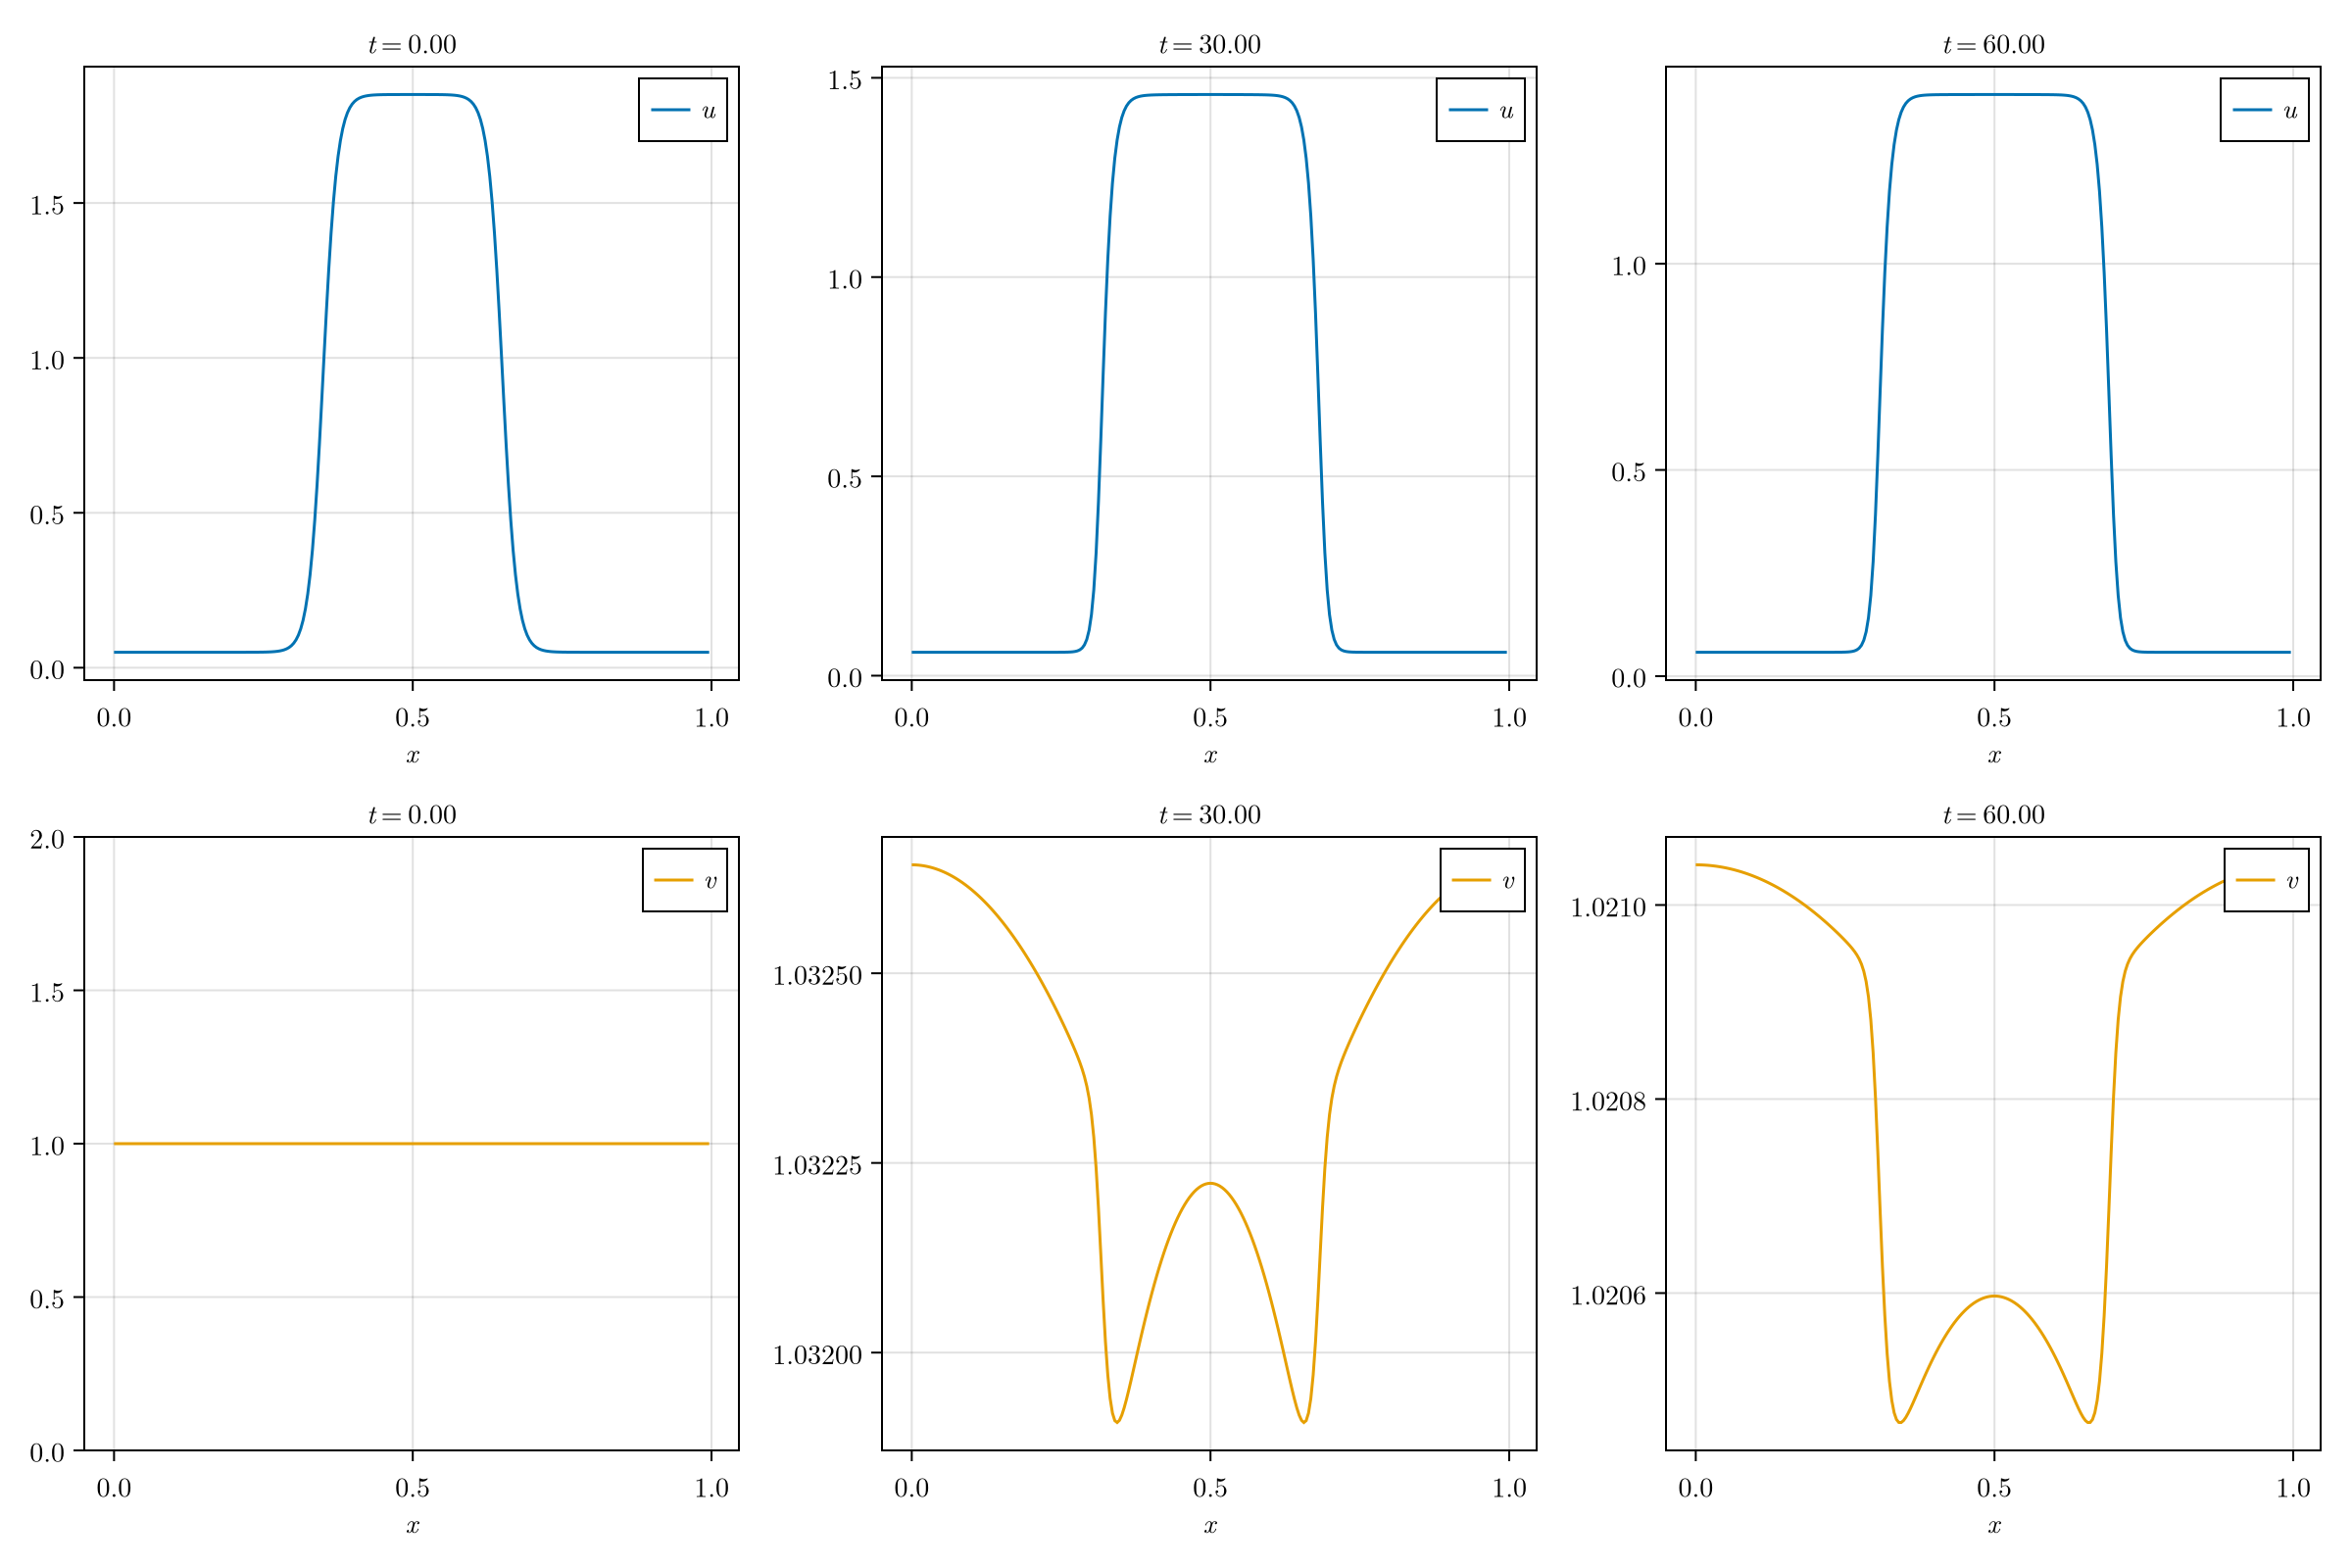

In [16]:
plot_profiles(sols[2]; plot_times = [0.0, 30.0, 60.0], size = (400,400), axislabelsize = nothing,
                        ticklabelsize = nothing, titlesize = nothing)

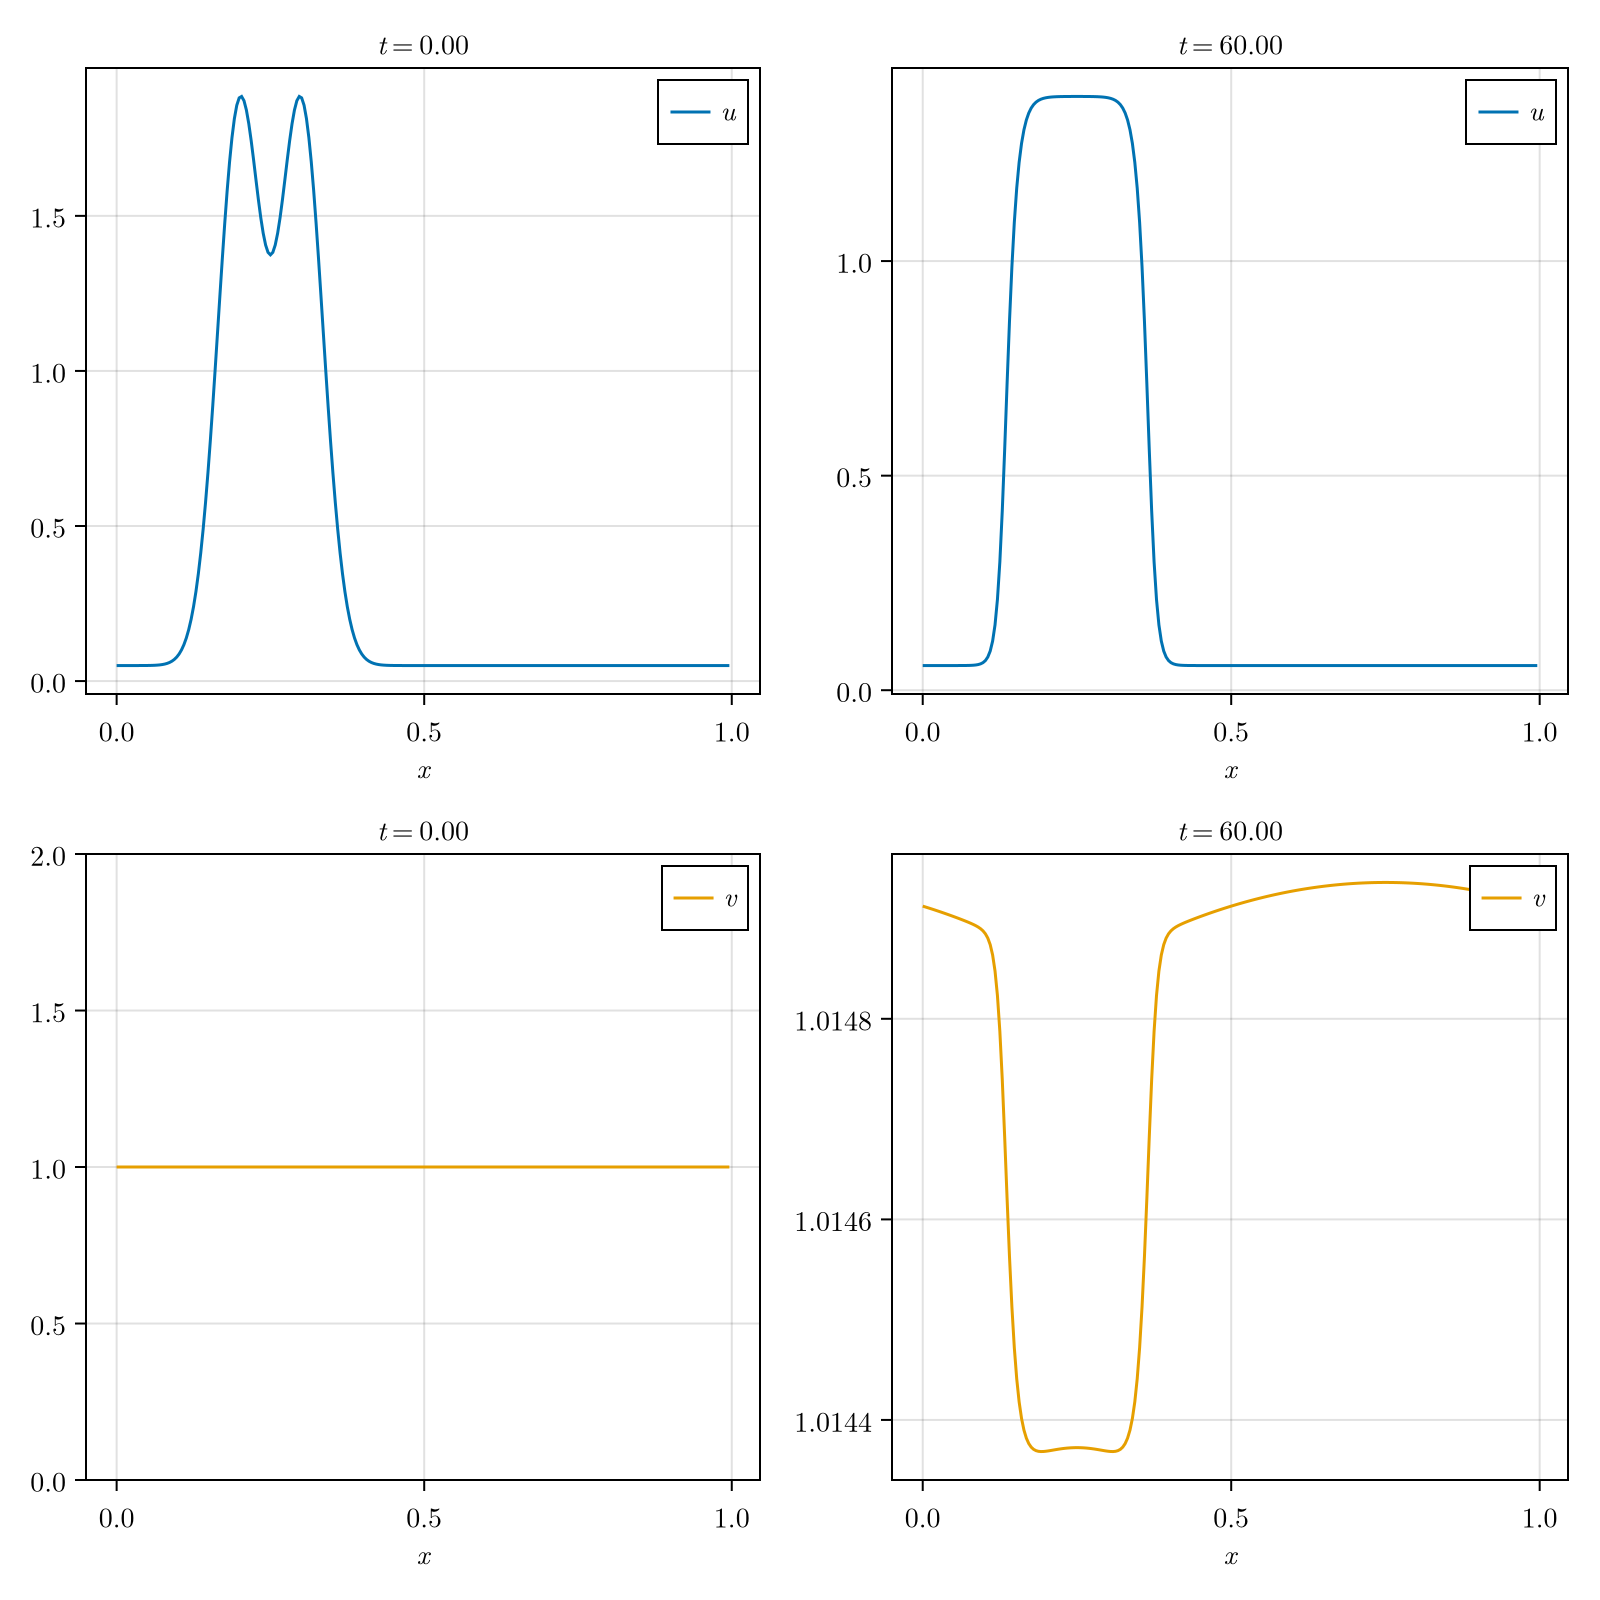

In [18]:
plot_profiles(sols[3]; plot_times = [0.0, 60.0], size = (400,400), axislabelsize = nothing,
                        ticklabelsize = nothing, titlesize = nothing)

In [9]:
# Gierer–Meinhardt activator–inhibitor kinetics
f_spike(u, v, x, t, p) = -u + u^2 / v
g_spike(u, v, x, t, p) = -v + u^2

spike_sol = rd_solve_two_species(
    f = f_spike,
    g = g_spike,
    D_u = 0.0004,
    D_v = 0.1,
    u0_fun = x -> 0.001 + 20.0 / cosh((x - 0.5) / 0.04)^2,
    v0_fun = x -> 20.0,
    ℓ = 1.0,
    tspan = (0.0, 60.0),
    dt = 0.001,
    N = 256,
);

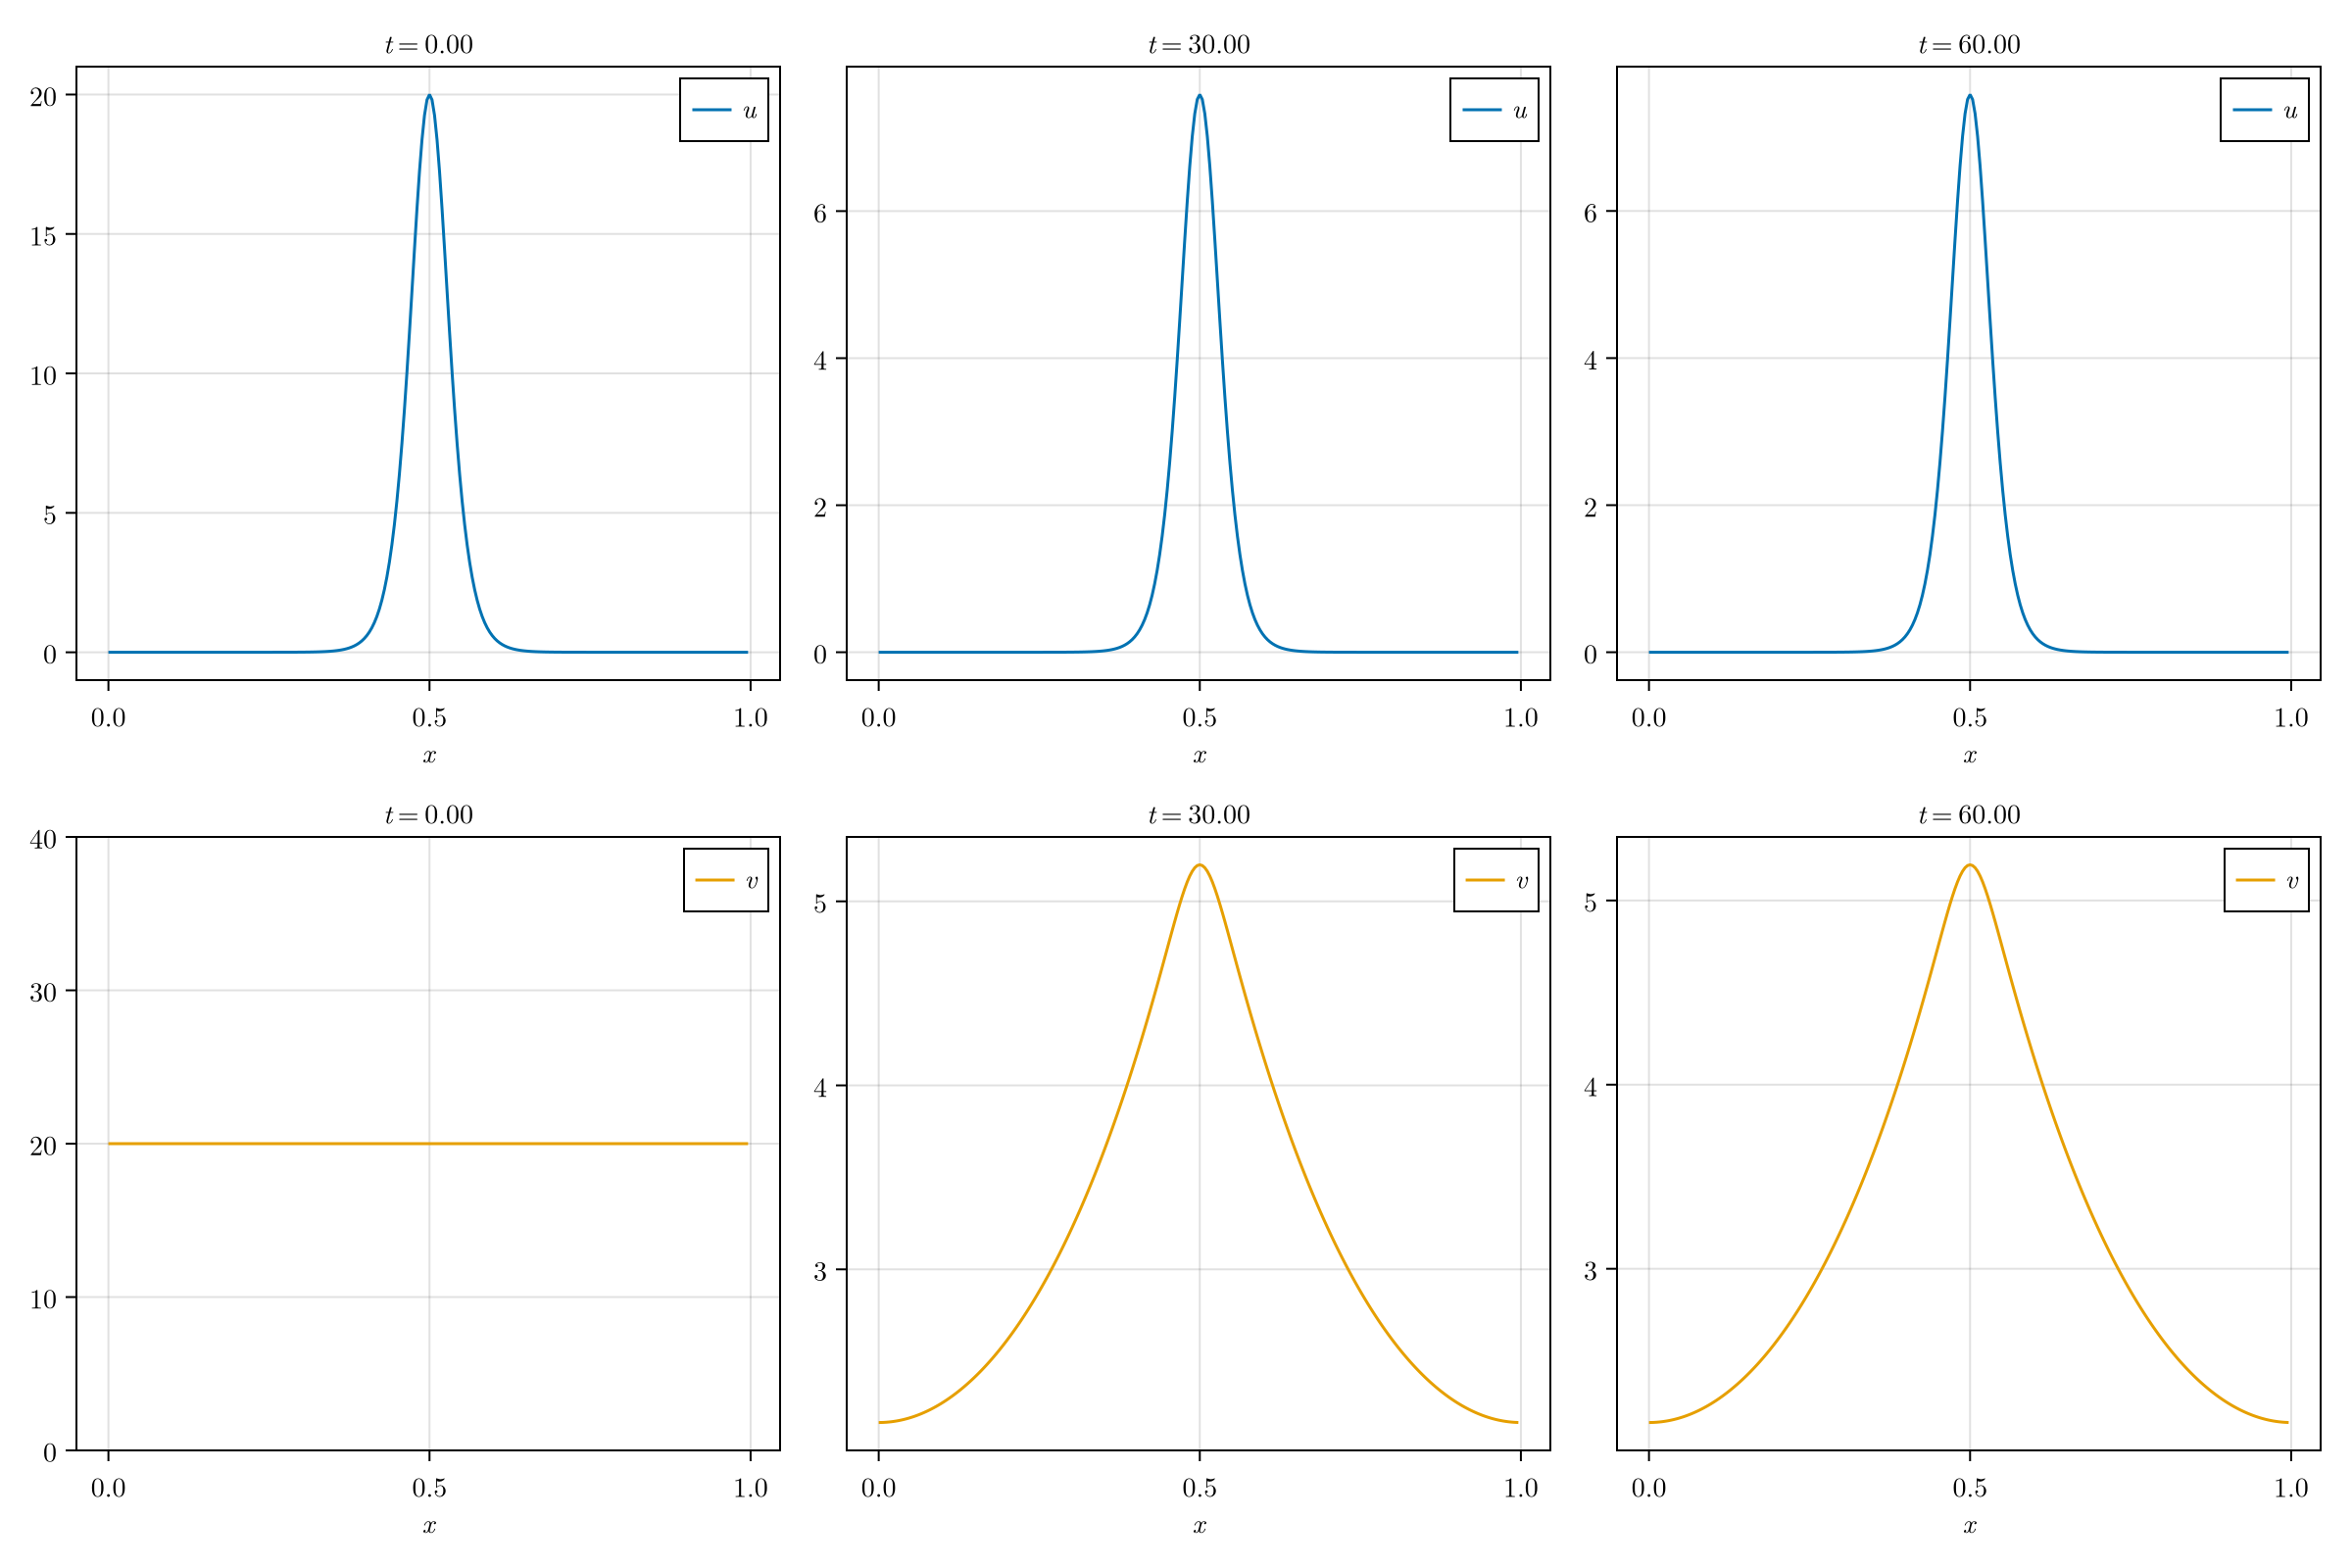

In [10]:
plot_profiles(spike_sol; plot_times = [0.0, 30.0, 60.0], size = (400,400), axislabelsize = nothing,
                        ticklabelsize = nothing, titlesize = nothing)